<a href="https://colab.research.google.com/github/anaayaoli/TFM/blob/main/An%C3%A1lisis_datos_definitivo_corregido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns


PERC_COLOR  = "#2563EB"
REAS_COLOR  = "#7C3AED"
CLIN_COLOR  = "#0F766E"
WARN_COLOR  = "#DC2626"
SNS_PAL = [
    "#2563EB","#7C3AED","#0EA5E9","#10B981",
    "#F59E0B","#EF4444","#EC4899","#14B8A6",
    "#6366F1","#84CC16","#F97316",
]

sns.set_theme(context="paper", style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi":          110,
    "savefig.dpi":         300,
    "savefig.bbox":        "tight",
    "pdf.fonttype":        42,
    "ps.fonttype":         42,
    "axes.titleweight":    "bold",
    "axes.spines.top":     False,
    "axes.spines.right":   False,
})

OUT = Path("figures")
OUT.mkdir(exist_ok=True)

def save(fig, name):
    fig.savefig(OUT / f"{name}.png")
    plt.close(fig)
    print(f" {name}.png")



PERC_VOCAB = [
    "Lexical and Phrase-Level Recognition",
    "Speaker Identification",
    "Paralinguistic/Emotion Recognition",
    "Speech Activity, Turn-Taking and Overlap Detection",
    "Language Identification",
    "Audio Quality, Artifacts & Channel Characteristics",
    "Prosody Detection",
    "Speaker Demographics",
    "Syntactic and Sentence-Structure Processing",
]
REAS_VOCAB = [
    "Speaker Intent, Pragmatics and Causal Reasoning",
    "Semantic Abstraction and Summarization",
    "Logical/Consistency Reasoning",
    "Ground Truth and World Knowledge Integration",
    "Quantitative Reasoning (Counting/Arithmetic Comparison)",
    "Temporal and Ordering Reasoning",
    "Social Role and Relationship Inference",
    "Comparative and Preference-Based Judgments",
    "Cross-frontier Entity Linking",
    "Coherence and Discourse Structure",
]

PERC_SHORT = {
    "Lexical and Phrase-Level Recognition":              "Lexical Recognition",
    "Speaker Identification":                            "Speaker Identification",
    "Paralinguistic/Emotion Recognition":                "Paralinguistic/Emotion",
    "Speech Activity, Turn-Taking and Overlap Detection":"Speech Activity & Turn-Taking",
    "Language Identification":                           "Language Identification",
    "Audio Quality, Artifacts & Channel Characteristics":"Audio Quality & Artifacts",
    "Prosody Detection":                                 "Prosody Detection",
    "Speaker Demographics":                              "Speaker Demographics",
    "Syntactic and Sentence-Structure Processing":       "Syntactic Processing",
}
REAS_SHORT = {
    "Speaker Intent, Pragmatics and Causal Reasoning":        "Intent & Pragmatics",
    "Semantic Abstraction and Summarization":                 "Semantic Abstraction",
    "Logical/Consistency Reasoning":                          "Logical Reasoning",
    "Ground Truth and World Knowledge Integration":           "World Knowledge",
    "Quantitative Reasoning (Counting/Arithmetic Comparison)":"Quantitative Reasoning",
    "Temporal and Ordering Reasoning":                        "Temporal Reasoning",
    "Social Role and Relationship Inference":                 "Social Role Inference",
    "Comparative and Preference-Based Judgments":             "Comparative Judgments",
    "Cross-frontier Entity Linking":                          "Entity Linking",
    "Coherence and Discourse Structure":                      "Discourse Coherence",
}

def split_labels(cell, vocab):
    s = (cell or "").strip()
    if not s:
        return []
    found = []
    for name in sorted(vocab, key=len, reverse=True):
        if name in s:
            found.append(name)
            s = s.replace(name, "")
    return found

In [20]:
#CARGAR DATOS
with open("ESCUCHA.json", encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
meta = pd.json_normalize(df["aux_metadata"])
df = pd.concat([df.drop(columns=["aux_metadata", "categories"]), meta,
                df["categories"].apply(pd.Series).rename(
                    columns={"perception": "cat_perception",
                             "reasoning": "cat_reasoning"})], axis=1)

df["perception_labels"] = df["cat_perception"].apply(lambda c: split_labels(c, PERC_VOCAB))
df["reasoning_labels"]  = df["cat_reasoning"].apply(lambda c: split_labels(c, REAS_VOCAB))
df["n_perception"]      = df["perception_labels"].apply(len)
df["n_reasoning"]       = df["reasoning_labels"].apply(len)
df["has_second_audio"]  = df["url_2"].fillna("").str.strip().ne("")
df["total_duration"]    = pd.to_numeric(df["total_duration"], errors="coerce")
df["n_choices"]         = df["choices"].apply(len)
for col in ("sex_1", "sex_2"):
    if col in df.columns:
        df[col] = df[col].fillna("").str.strip().replace({"Male": "M", "Female": "F"})



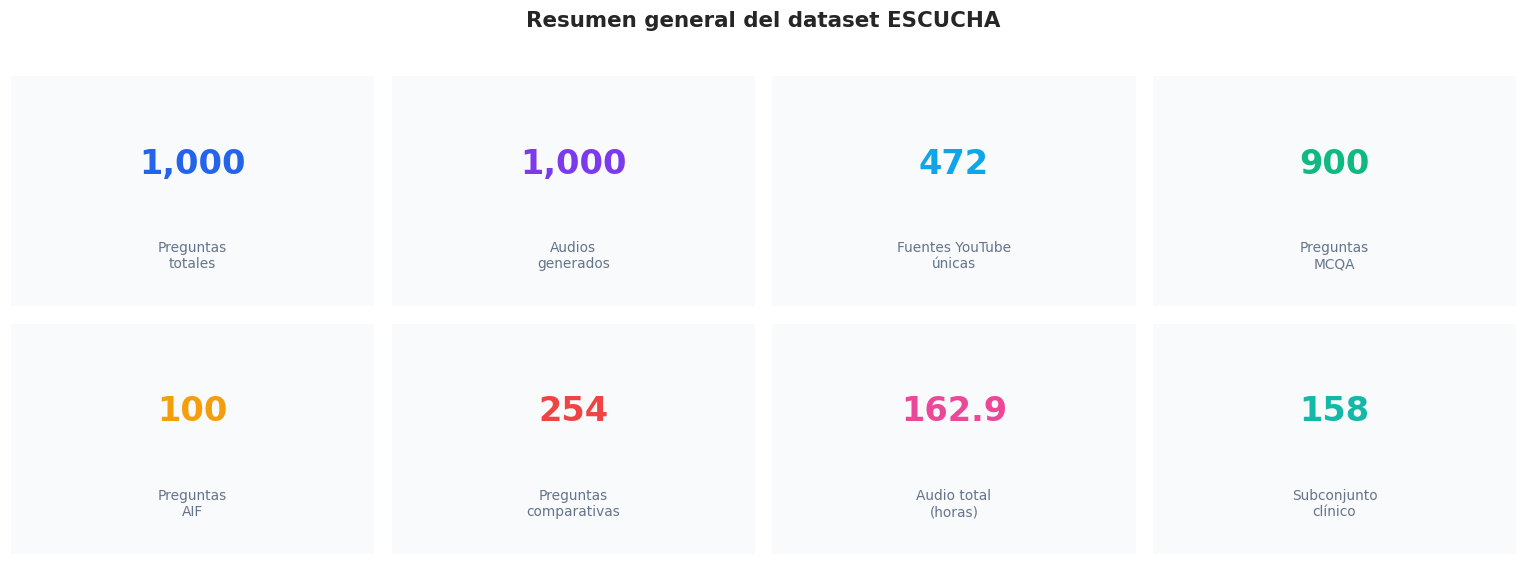

 fig1_resumen_general.png


In [35]:
#RESUMEN GENERAL
all_urls = set()
for row in raw:
    for k in ("url_1", "url_2"):
        v = row["aux_metadata"].get(k, "")
        if v:
            all_urls.add(v)

cards = {
    "Preguntas\ntotales":        (len(df),                        "#2563EB"),
    "Audios\ngenerados":         (df["audio_path"].nunique(),      "#7C3AED"),
    "Fuentes YouTube\núnicas":   (len(all_urls),                   "#0EA5E9"),
    "Preguntas\nMCQA":           (int((df.eval_type=="mcqa").sum()),"#10B981"),
    "Preguntas\nAIF":            (int((df.eval_type=="aif").sum()), "#F59E0B"),
    "Preguntas\ncomparativas":   (int(df.has_second_audio.sum()),   "#EF4444"),
    "Audio total\n(horas)":      (round(df.total_duration.sum()/3600,1), "#EC4899"),
    "Subconjunto\nclínico":      (int((df["disease_1"].fillna("").str.strip()!="").sum()), "#14B8A6"),
}

fig, axes = plt.subplots(2, 4, figsize=(14, 5))
fig.suptitle("Resumen general del dataset ESCUCHA", fontsize=14, fontweight="bold", y=1.02)
for ax, (label, (val, color)) in zip(axes.flat, cards.items()):
    ax.set_facecolor("#F8FAFC")
    ax.text(0.5, 0.62, f"{val:,}" if isinstance(val, int) else str(val),
            ha="center", va="center", fontsize=22, fontweight="bold",
            color=color, transform=ax.transAxes)
    ax.text(0.5, 0.22, label, ha="center", va="center",
            fontsize=9, color="#64748B", transform=ax.transAxes)
    for sp in ax.spines.values():
        sp.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()
save(fig, "fig1_resumen_general")

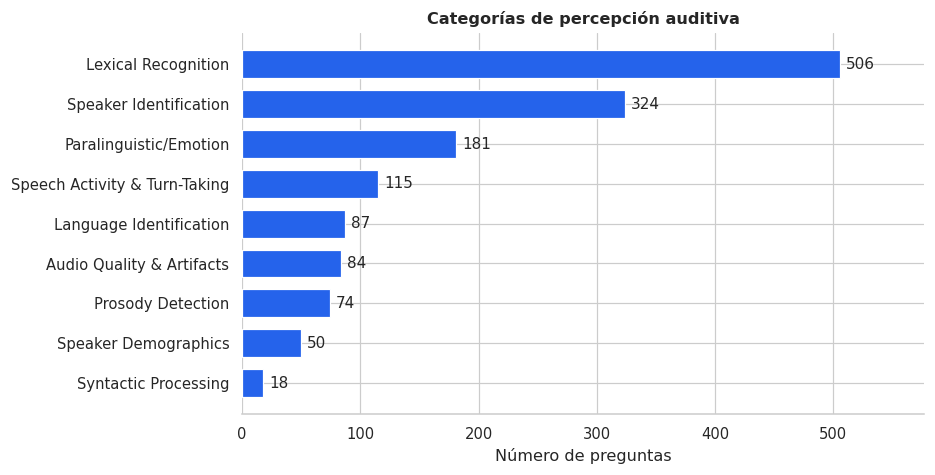

 fig2_perception_distribution.png


In [36]:
perc_counts = pd.Series(
    Counter(l for labs in df.perception_labels for l in labs)
).sort_values()
perc_short = perc_counts.rename(index=PERC_SHORT)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(perc_short.index, perc_short.values, color=PERC_COLOR, edgecolor="white", height=0.7)
for i, v in enumerate(perc_short.values):
    ax.text(v + perc_short.max() * 0.01, i, str(v), va="center", fontsize=10)
ax.set_xlabel("Número de preguntas")
ax.set_title("Categorías de percepción auditiva")
ax.set_xlim(0, perc_short.max() * 1.14)
sns.despine(ax=ax, left=True)
plt.show()
save(fig, "fig2_perception_distribution")

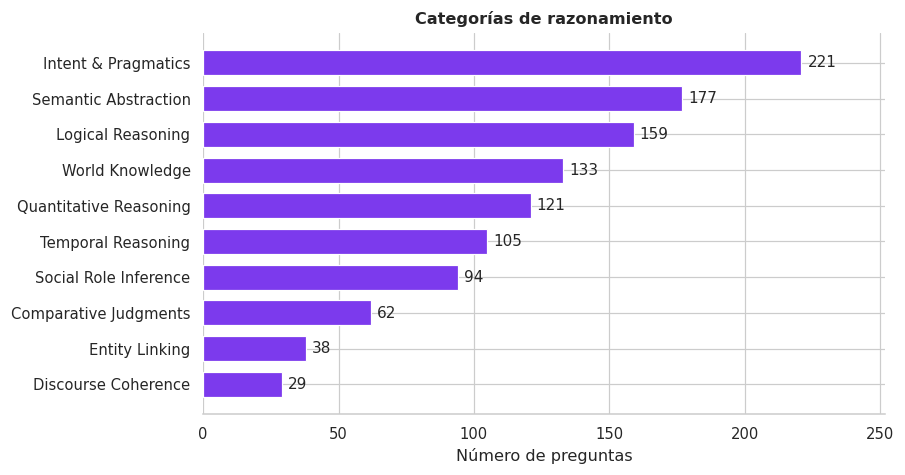

 fig3_reasoning_distribution.png


In [37]:
reas_counts = pd.Series(
    Counter(l for labs in df.reasoning_labels for l in labs)
).sort_values()
reas_short = reas_counts.rename(index=REAS_SHORT)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(reas_short.index, reas_short.values, color=REAS_COLOR, edgecolor="white", height=0.7)
for i, v in enumerate(reas_short.values):
    ax.text(v + reas_short.max() * 0.01, i, str(v), va="center", fontsize=10)
ax.set_xlabel("Número de preguntas")
ax.set_title("Categorías de razonamiento")
ax.set_xlim(0, reas_short.max() * 1.14)
sns.despine(ax=ax, left=True)
plt.show()
save(fig, "fig3_reasoning_distribution")


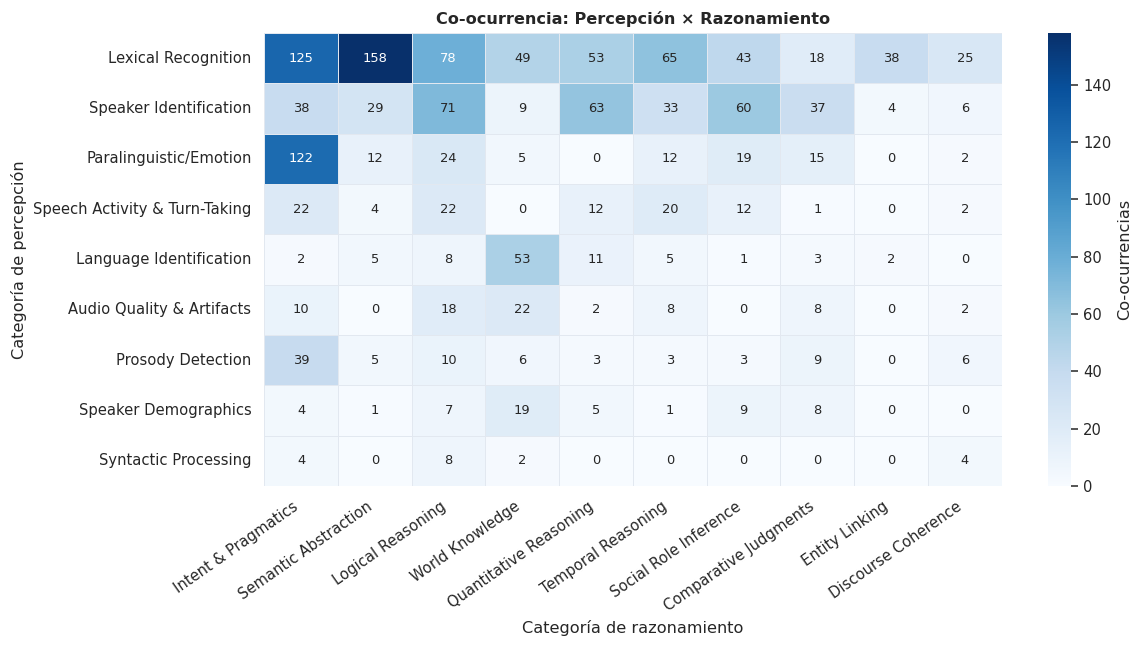

 fig4_heatmap_coocurrencia.png


In [38]:
perc_order = perc_counts.sort_values(ascending=False).index.tolist()
reas_order = reas_counts.sort_values(ascending=False).index.tolist()
co = pd.DataFrame(0, index=perc_order, columns=reas_order, dtype=int)
for p_labs, r_labs in zip(df.perception_labels, df.reasoning_labels):
    for p in p_labs:
        for r in r_labs:
            if p in co.index and r in co.columns:
                co.loc[p, r] += 1

co_disp = co.rename(index=PERC_SHORT, columns=REAS_SHORT)

fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(co_disp, annot=True, fmt="d", cmap="Blues", ax=ax,
            cbar_kws={"label": "Co-ocurrencias"},
            linewidths=0.4, linecolor="#E2E8F0",
            annot_kws={"size": 8.5})
ax.set_title("Co-ocurrencia: Percepción × Razonamiento")
ax.set_xlabel("Categoría de razonamiento")
ax.set_ylabel("Categoría de percepción")
plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
plt.setp(ax.get_yticklabels(), rotation=0)
fig.tight_layout()
plt.show()
save(fig, "fig4_heatmap_coocurrencia")

 fig5a_duracion_histograma.png


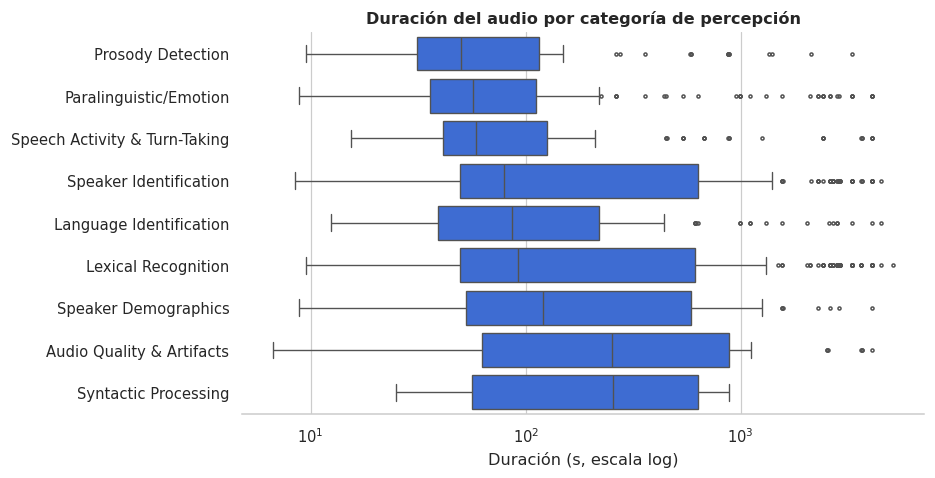

 fig5b_duracion_por_percepcion.png


In [39]:
dur = df["total_duration"].dropna()
lo  = max(1.0, dur.min())
hi  = dur.max() * 1.05
bins = np.logspace(np.log10(lo), np.log10(hi), 40)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dur, bins=bins, color=PERC_COLOR, edgecolor="white", alpha=0.9)
ax.set_xscale("log")
ax.axvline(dur.median(), color="black", linestyle="--", linewidth=1.5,
           label=f"Mediana = {dur.median():.0f} s")
ax.set_xlabel("Duración del audio por pregunta (s, escala log)")
ax.set_ylabel("Número de preguntas")
ax.set_title(f"Distribución de duración (n={len(dur)}, total {dur.sum()/3600:.1f} h)")
ax.legend(frameon=False)
sns.despine(ax=ax)
save(fig, "fig5a_duracion_histograma")

# Boxplot duración por categoría de percepción
rows_dur = []
for labs, d in zip(df["perception_labels"], df["total_duration"]):
    if pd.isna(d):
        continue
    for lab in labs:
        rows_dur.append({"categoria": PERC_SHORT.get(lab, lab), "duracion": d})
per_cat = pd.DataFrame(rows_dur)
order_box = (per_cat.groupby("categoria")["duracion"]
             .median().sort_values(ascending=True).index.tolist())

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=per_cat, x="duracion", y="categoria", order=order_box,
            color=PERC_COLOR, fliersize=2, linewidth=0.9, ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Duración (s, escala log)")
ax.set_ylabel("")
ax.set_title("Duración del audio por categoría de percepción")
sns.despine(ax=ax, left=True)
plt.show()
save(fig, "fig5b_duracion_por_percepcion")


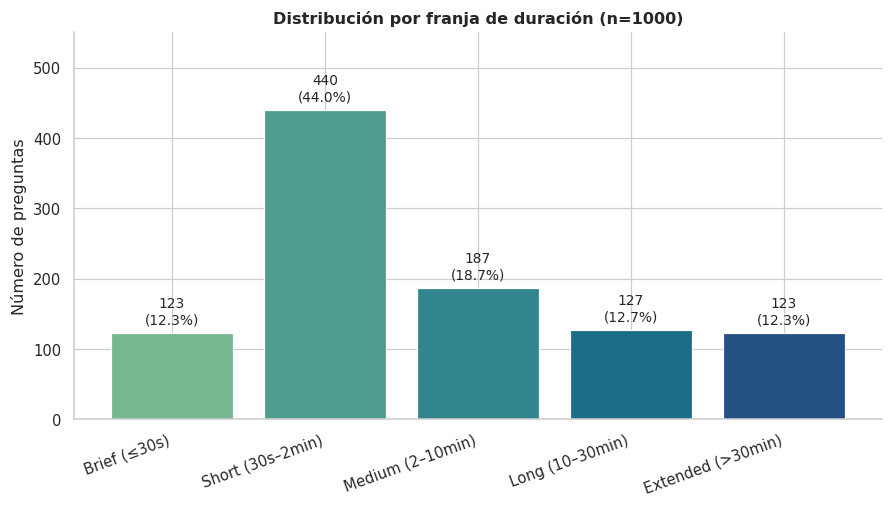

 fig6_length_buckets.png


In [40]:
bucket_order = [
    "Brief (≤30s)", "Short (30s–2min)", "Medium (2–10min)",
    "Long (10–30min)", "Extended (>30min)",
]
bucket_counts = df["length_type"].value_counts().reindex(bucket_order, fill_value=0)
pal_buckets   = sns.color_palette("crest", len(bucket_order))

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)
bars = ax.bar(bucket_order, bucket_counts.values,
              color=pal_buckets, edgecolor="white")
for bar, v in zip(bars, bucket_counts.values):
    pct = v / bucket_counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            v + bucket_counts.max() * 0.02,
            f"{v}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Número de preguntas")
ax.set_title(f"Distribución por franja de duración (n={bucket_counts.sum()})")
ax.set_ylim(0, bucket_counts.max() * 1.25)
plt.setp(ax.get_xticklabels(), rotation=20, ha="right")
sns.despine(ax=ax)
plt.show()
save(fig, "fig6_length_buckets")

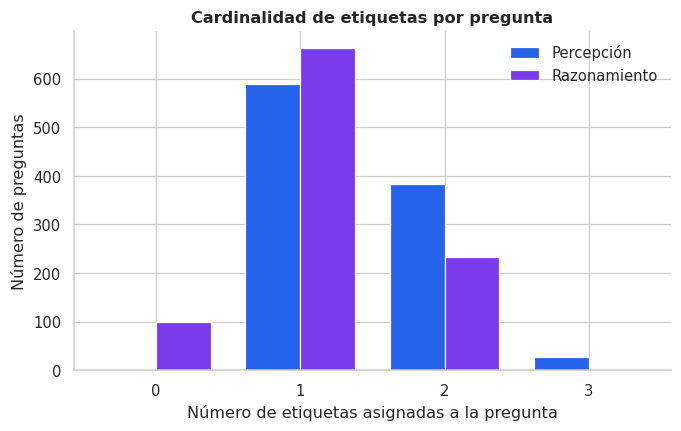

 fig7_label_cardinality.png


In [41]:
max_k = int(max(df.n_perception.max(), df.n_reasoning.max()))
ks = list(range(0, max_k + 1))
perc_card = df.n_perception.value_counts().reindex(ks, fill_value=0)
reas_card = df.n_reasoning.value_counts().reindex(ks, fill_value=0)

x = np.arange(len(ks))
w = 0.38
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, perc_card.values, w, label="Percepción", color=PERC_COLOR, edgecolor="white")
ax.bar(x + w/2, reas_card.values, w, label="Razonamiento", color=REAS_COLOR, edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(ks)
ax.set_xlabel("Número de etiquetas asignadas a la pregunta")
ax.set_ylabel("Número de preguntas")
ax.set_title("Cardinalidad de etiquetas por pregunta")
ax.legend(frameon=False)
sns.despine(ax=ax)
plt.show()
save(fig, "fig7_label_cardinality")

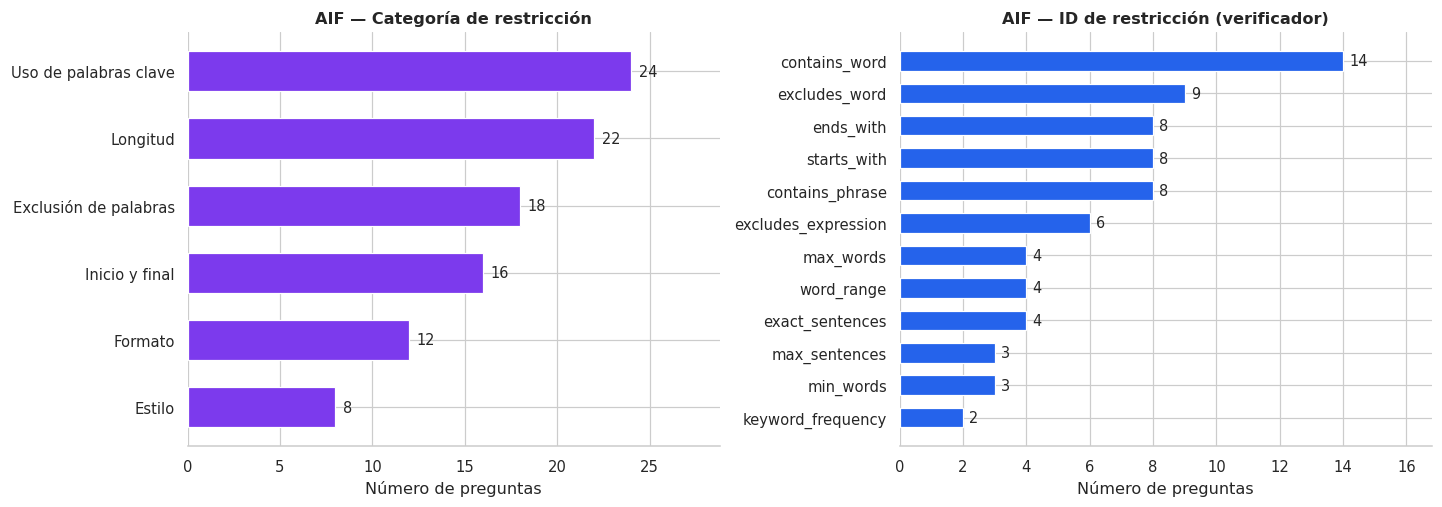

 fig9_aif_constraints.png


In [43]:
aif_df = df[df.eval_type == "aif"]

cat_cts = (aif_df["constraint_category"].replace("", np.nan)
           .dropna().value_counts().sort_values())
id_cts  = (aif_df["constraint_id"].replace("", np.nan)
           .dropna().value_counts().head(12).sort_values())

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

axes[0].barh(cat_cts.index, cat_cts.values, color=REAS_COLOR, edgecolor="white", height=0.6)
for i, v in enumerate(cat_cts.values):
    axes[0].text(v + 0.4, i, str(v), va="center", fontsize=9.5)
axes[0].set_xlabel("Número de preguntas")
axes[0].set_title("AIF — Categoría de restricción")
axes[0].set_xlim(0, cat_cts.max() * 1.2)
sns.despine(ax=axes[0], left=True)

axes[1].barh(id_cts.index, id_cts.values, color=PERC_COLOR, edgecolor="white", height=0.6)
for i, v in enumerate(id_cts.values):
    axes[1].text(v + 0.2, i, str(v), va="center", fontsize=9.5)
axes[1].set_xlabel("Número de preguntas")
axes[1].set_title("AIF — ID de restricción (verificador)")
axes[1].set_xlim(0, id_cts.max() * 1.2)
sns.despine(ax=axes[1], left=True)
plt.show()
save(fig, "fig9_aif_constraints")


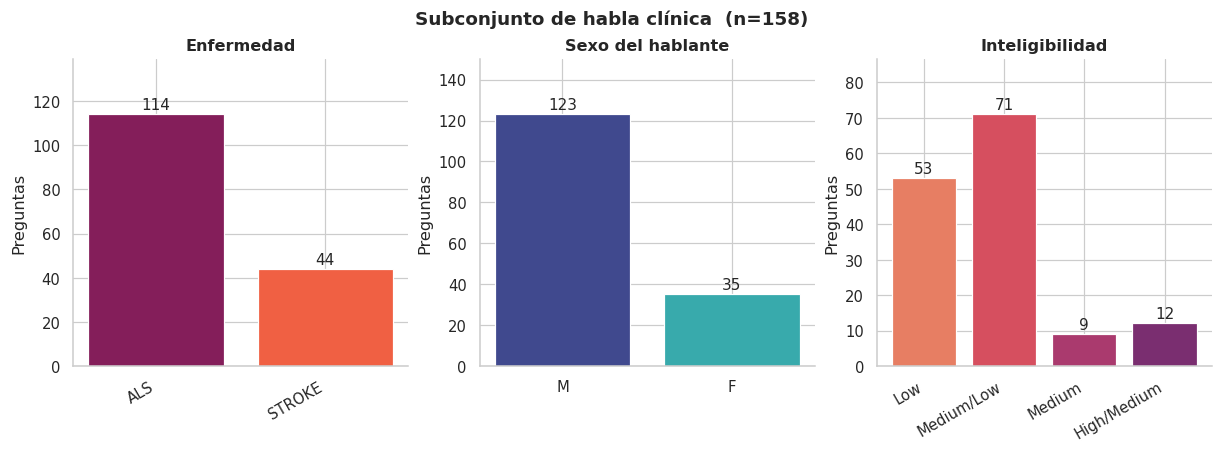

 fig11_subset_clinico.png


In [44]:
clinical = df[df["disease_1"].fillna("").str.strip() != ""]

def cat_cts_series(s):
    return s.replace("", np.nan).dropna().value_counts()

disease = cat_cts_series(clinical["disease_1"])
sex     = cat_cts_series(clinical["sex_1"])
intell_order_labels = ["Low", "Medium/Low", "Medium", "High/Medium", "High"]
intell_raw = cat_cts_series(clinical["intelligibility_1"])
intell = intell_raw.reindex([k for k in intell_order_labels if k in intell_raw.index])

fig, axes = plt.subplots(1, 3, figsize=(11, 4), constrained_layout=True)
panels = [
    (axes[0], disease, "Enfermedad",       sns.color_palette("rocket", len(disease)),  30),
    (axes[1], sex,     "Sexo del hablante", sns.color_palette("mako",   len(sex)),       0),
    (axes[2], intell,  "Inteligibilidad",   sns.color_palette("flare",  len(intell)),    30),
]
for ax, series, title, pal, rot in panels:
    ax.bar(series.index.astype(str), series.values, color=pal, edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Preguntas")
    for i, v in enumerate(series.values):
        ax.text(i, v + max(series.values) * 0.02, str(v),
                ha="center", fontsize=10)
    ax.set_ylim(0, max(series.values) * 1.22)
    if rot:
        plt.setp(ax.get_xticklabels(), rotation=rot, ha="right")
    sns.despine(ax=ax)
fig.suptitle(f"Subconjunto de habla clínica  (n={len(clinical)})",
             fontsize=12, fontweight="bold")
plt.show()
save(fig, "fig11_subset_clinico")

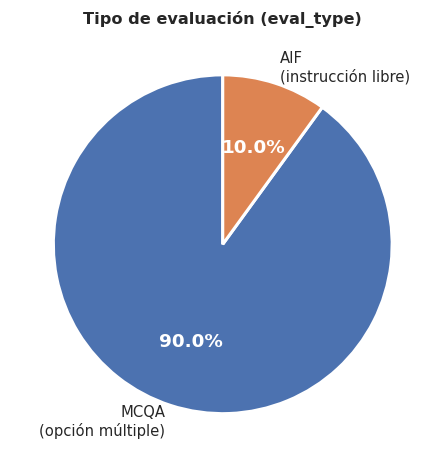

 12_eval_type.png


In [45]:
#por tipo de evaluación
fig, ax = plt.subplots(figsize=(5, 5))
counts = df["eval_type"].value_counts()
wedges, texts, autotexts = ax.pie(
    counts,
    labels=["MCQA\n(opción múltiple)", "AIF\n(instrucción libre)"],    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(linewidth=2, edgecolor="white"),
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_color("white")
    at.set_fontweight("bold")
ax.set_title("Tipo de evaluación (eval_type)")
plt.show()

save(fig, "12_eval_type")